In [9]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [2]:
ratings = pd.read_csv("../data/ratings.csv")
movies = pd.read_csv("../data/movies.csv")


Create User–Item Matrix

In [4]:
user_item = ratings.pivot(
    index="userId",
    columns="movieId",
    values="rating"
)
print(user_item.head())
print(user_item.shape)

movieId  1       2       3       4       5       6       7       8       \
userId                                                                    
1           4.0     NaN     4.0     NaN     NaN     4.0     NaN     NaN   
2           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
3           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
4           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
5           4.0     NaN     NaN     NaN     NaN     NaN     NaN     NaN   

movieId  9       10      ...  193565  193567  193571  193573  193579  193581  \
userId                   ...                                                   
1           NaN     NaN  ...     NaN     NaN     NaN     NaN     NaN     NaN   
2           NaN     NaN  ...     NaN     NaN     NaN     NaN     NaN     NaN   
3           NaN     NaN  ...     NaN     NaN     NaN     NaN     NaN     NaN   
4           NaN     NaN  ...     NaN     NaN     NaN     NaN     NaN     N

Missing values

In [7]:
total_missing = user_item.isna().sum().sum()
total_entries = user_item.size

sparsity = total_missing / total_entries
sparsity * 100
#98.3%missing values


np.float64(98.30003169443864)

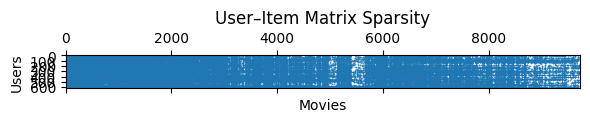

In [10]:
plt.figure(figsize=(6,4))
plt.spy(user_item, markersize=0.2)
plt.title("User–Item Matrix Sparsity")
plt.xlabel("Movies")
plt.ylabel("Users")
plt.tight_layout()
plt.show()


User–Item Matrix?

A 2D matrix where rows are users, columns are items, and values are interactions (ratings).

Why is it sparse?

Users consume only a tiny fraction of available items
Large item catalog
Real-world behavior

Why is sparsity a problem?
Hard to compute similarities directly
Cold-start issues
Motivates:
Matrix Factorization
Embeddings
Neural recommenders